# huble st

The Cosmic Origins Spectrograph (COS) 是HST上的紫外光谱仪。

MAST是HST档案馆

In [47]:
from astroquery.mast import Observations
from pathlib import Path
from astropy.table import Table
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk") 

plt.rcParams['figure.dpi'] = 100
colors = sns.color_palette("muted")

*proposal* 意为申请书，所有id就是科研项目id

In [10]:
obs_from_proposal = Observations.query_criteria(proposal_id = '15366')

In [11]:
products_from_proposal = Observations.get_product_list(obs_from_proposal)

In [16]:
products_from_proposal[:5]

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str9,str4,str8,str48,str62,str1,str98,str9,str28,str12,str1,str7,str5,str87,str70,int64,str9,str6,int64,str30
198779689,HLSP,spectrum,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt,FITS,D,mast:HLSP/ullyses/av-75/dr7/hlsp_ullyses_fuse_fuv_av-75_lwrs_dr7_aspec.fits,SCIENCE,--,--,--,ULLYSES,dr7,12805_13122_13522_13931_13969_14437_14855_14909_15366_15385_15536_15774_16230_7437_P115,hlsp_ullyses_fuse_fuv_av-75_lwrs_dr7_aspec.fits,463680,25868962,PUBLIC,4,E140M;G130M;G160M;G230LB;G430L
198779689,HLSP,spectrum,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt,FITS,D,mast:HLSP/ullyses/av-75/dr7/hlsp_ullyses_fuse_fuv_av-75_lwrs_dr7_aspec.fits,SCIENCE,--,--,--,ULLYSES,dr7,12805_13122_13522_13931_13969_14437_14855_14909_15366_15385_15536_15774_16230_7437_P115,hlsp_ullyses_fuse_fuv_av-75_lwrs_dr7_aspec.fits,463680,25868963,PUBLIC,4,E140M;G130M;G160M;G230LB;G430L
198779689,HLSP,spectrum,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt,FITS,D,mast:HLSP/ullyses/av-75/dr7/hlsp_ullyses_fuse_fuv_av-75_lwrs_dr7_aspec.fits,SCIENCE,--,--,--,ULLYSES,dr7,12805_13122_13522_13931_13969_14437_14855_14909_15366_15385_15536_15774_16230_7437_P115,hlsp_ullyses_fuse_fuv_av-75_lwrs_dr7_aspec.fits,463680,25868964,PUBLIC,4,E140M;G130M;G160M;G230LB;G430L
198779689,HLSP,spectrum,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt,FITS,D,mast:HLSP/ullyses/av-75/dr7/hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt_dr7_preview-spec.fits,SCIENCE,--,--,--,ULLYSES,dr7,12805_13122_13522_13931_13969_14437_14855_14909_15366_15385_15536_15774_16230_7437_P115,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt_dr7_preview-spec.fits,1621440,25868962,PUBLIC,4,E140M;G130M;G160M;G230LB;G430L
198779689,HLSP,spectrum,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt,FITS,D,mast:HLSP/ullyses/av-75/dr7/hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt_dr7_preview-spec.fits,SCIENCE,--,--,--,ULLYSES,dr7,12805_13122_13522_13931_13969_14437_14855_14909_15366_15385_15536_15774_16230_7437_P115,hlsp_ullyses_hst-fuse_fuse-cos-stis_av-75_uv-opt_dr7_preview-spec.fits,1621440,25868963,PUBLIC,4,E140M;G130M;G160M;G230LB;G430L


`products_from_proposal` 所有相关测验数据

In [18]:
products_to_download = Observations.filter_products(
    products_from_proposal,
    productSubGroupDescription = ['X1DSUM']
)

*X1DSUM* 文件表示 接收到的光谱信息

In [19]:
data = Observations.download_products(products_to_download)

INFO: 3 of 6 products were duplicates. Only returning 3 unique product(s). [astroquery.mast.utils]


In [20]:
data

Local Path,Status,Message,URL
str50,str8,object,object
.\mastDownload\HST\ldm701010\ldm701010_x1dsum.fits,COMPLETE,None,None
.\mastDownload\HST\ldm701020\ldm701020_x1dsum.fits,COMPLETE,None,None
.\mastDownload\HST\ldm701030\ldm701030_x1dsum.fits,COMPLETE,None,None


In [21]:
onecell_x1dsum_products = [Path(local_path) for local_path in data['Local Path']]

In [22]:
onecell_x1dsum_products

[WindowsPath('mastDownload/HST/ldm701010/ldm701010_x1dsum.fits'),
 WindowsPath('mastDownload/HST/ldm701020/ldm701020_x1dsum.fits'),
 WindowsPath('mastDownload/HST/ldm701030/ldm701030_x1dsum.fits')]

In [25]:
data = Table.read(onecell_x1dsum_products[0])

c:\Users\63517\miniconda3\envs\data-analysis\lib\site-packages\astropy\units\format\generic.py:575: UnitsWarning: 'erg /s /cm**2 /angstrom' contains multiple slashes, which is discouraged by the FITS standard
  warnings.warn(


In [26]:
data

SEGMENT,EXPTIME,NELEM,WAVELENGTH,FLUX,ERROR,ERROR_LOWER,GROSS,GCOUNTS,VARIANCE_FLAT,VARIANCE_COUNTS,VARIANCE_BKG,NET,BACKGROUND,DQ,DQ_WGT
,s,,Angstrom,erg / (Angstrom s cm2),erg / (Angstrom s cm2),erg / (Angstrom s cm2),ct / s,ct,ct,ct,ct,ct / s,ct / s,,
bytes4,float64,int32,float64[16384],float32[16384],float32[16384],float32[16384],float32[16384],float32[16384],float32[16384],float32[16384],float32[16384],float32[16384],float32[16384],int16[16384],float32[16384]
FUVA,1552.064,16384,1211.0559046770986 .. 1374.2763842150725,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,128 .. 128,0.0 .. 0.0
FUVB,1552.064,16384,1058.0549130803543 .. 1221.0733642361613,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,0.0 .. 0.0,128 .. 128,0.0 .. 0.0


cos仪器中，这两个频道不能同时开始。 光只能进入其中一个探测器
- FUV探测器 远紫外线
  - 900-2100A
  - 数据分为FUVA和FUVB两部分。
- NUV探测器 近紫外线
  - 1600-3200A
- 

In [36]:
# FUVA
wvln_A,  wvln_B= data['WAVELENGTH'][0],data['WAVELENGTH'][1]
flux_A, flux_B  = data['FLUX'][0],data['FLUX'][1]
segment_A, segment_B= data['SEGMENT'][0],data['SEGMENT'][1]


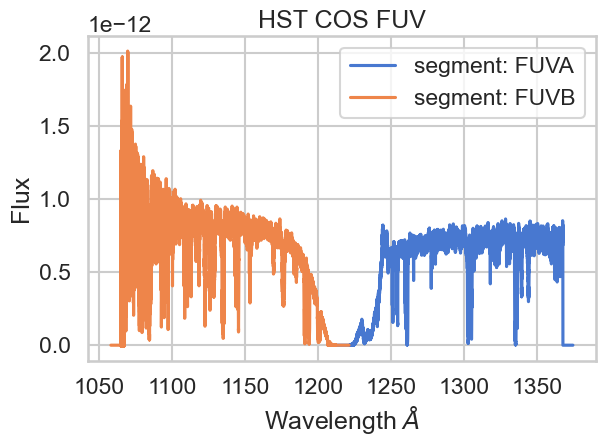

In [ ]:
plt.plot(wvln_A, flux_A, c=colors[0], label = f'segment: {segment_A}')
plt.plot(wvln_B, flux_B, c=colors[1], label = f'segment: {segment_B}')
plt.title('HST COS FUV')
plt.xlabel('Wavelength $\AA$')
plt.ylabel('Flux')
plt.legend()
plt.tight_layout()

研究下凹陷的局部

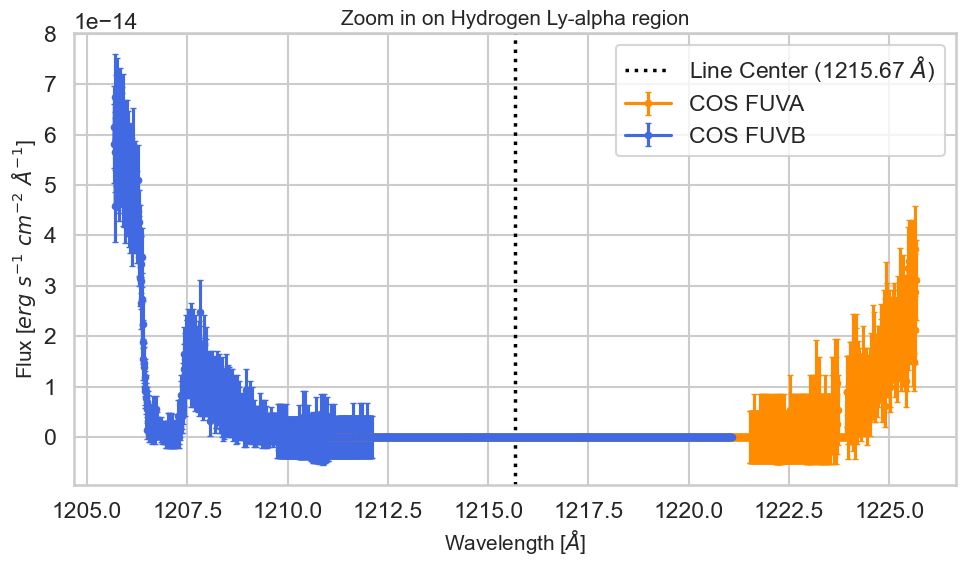

In [59]:
line_center = 1215.67
wvln_extent = 10  # 左右各看 5 埃

# --- 处理数据 A 段 ---
wvln_A, flux_A, fluxErr_A = data["WAVELENGTH", "FLUX", "ERROR"][0]
mask_A = (wvln_A > line_center - wvln_extent) & (wvln_A < line_center + wvln_extent)

# --- 处理数据 B 段 ---
wvln_B, flux_B, fluxErr_B = data["WAVELENGTH", "FLUX", "ERROR"][1]
mask_B = (wvln_B > line_center - wvln_extent) & (wvln_B < line_center + wvln_extent)

plt.figure(figsize=(10, 6))

plt.axvline(x=line_center, c='black', linewidth=2.5, linestyle='dotted', 
            label=f'Line Center ({line_center} $\AA$)')

if any(mask_A):
    plt.errorbar(x=wvln_A[mask_A], y=flux_A[mask_A], yerr=fluxErr_A[mask_A],
                 label='COS FUVA', marker='.', color='darkorange', capsize=2)

if any(mask_B):
    plt.errorbar(x=wvln_B[mask_B], y=flux_B[mask_B], yerr=fluxErr_B[mask_B],
                 label='COS FUVB', marker='.', color='royalblue', capsize=2)

# 设置标签和标题
plt.xlabel(r'Wavelength [$\AA$]', size=15)
plt.ylabel(r'Flux [$erg\ s^{-1}\ cm^{-2}\ \AA^{-1}$]', size=15)
plt.title(f'Zoom in on Hydrogen Ly-alpha region', size=15)

plt.legend()
plt.tight_layout()
plt.show()
